In [1]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from common import *

/home/wuke/anaconda3/envs/AIGEM/lib/python3.7/site-packages/Bio/pairwise2.py:283: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  BiopythonDeprecationWarning,


In [2]:
import numpy as np

def normalize_abundance_dict(abundance_dict):
    """
    将丰度字典的 value 归一化，使其和为 1。
    
    参数：
        abundance_dict (dict): 例如 {'A': 10, 'B': 30, 'C': 60}
    
    返回：
        dict: 归一化后的字典，例如 {'A': 0.1, 'B': 0.3, 'C': 0.6}
    """
    values = np.array(list(abundance_dict.values()), dtype=float)
    total = values.sum()
    if total > 0:
        normalized_values = values / total
    else:
        normalized_values = np.zeros_like(values)
    
    # 保留 key 的对应关系
    normalized_dict = dict(zip(abundance_dict.keys(), normalized_values))
    return normalized_dict


# input and output

In [3]:
experiment_file = '../../Data/L-DOPA_experimentdata.xlsx'

In [4]:
experiment_data = pd.read_excel(experiment_file,sheet_name = 'Sheet2')
experiment_data.head(3)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,0520A,0519A,0609A,0511A,0506A,0427A,0705A,...,0612A,0611A,0610C,0602B,0519B,0908B,0805A,0721C,0707B,0610A
0,Taxonomic rank,NCBI,strain,wulu1215_BKDL210003784-1A-9.txt,wulu1215_BKDL210003784-1A-8.txt,wulu1215_BKDL210003784-1A-7.txt,wulu1215_BKDL210003784-1A-5.txt,wulu1215_BKDL210003784-1A-4.txt,wulu1215_BKDL210003784-1A-3.txt,wulu1215_BKDL210003784-1A-20.txt,...,wulu1215_BKDL210003784-1A-18.txt,wulu1215_BKDL210003784-1A-17.txt,wulu1215_BKDL210003784-1A-16.txt,wulu1215_BKDL210003784-1A-13.txt,wulu1215_BKDL210003784-1A-11.txt,wulu0219_3-200908B_FKDL210012333-1a-9_HFJ7LCCX...,wulu0219_1-200805A_FKDL210012331-1a-11_HFJ7LCC...,wulu0219_1-200721C_FKDL210012331-1a-3_HFJ7LCCX...,wulu0219_1-200707B_FKDL210012331-1a-6_HFJ7LCCX...,wulu0219_1-200610A_FKDL210012331-1a-2_HFJ7LCCX...
1,C,1236,Gammaproteobacteria,4.93,2.59,9.96,1.11,2,0.65,3.7,...,1.26,7.44,0.72,0.6,0.72,0.58,0.65,1.58,3.2,1.67
2,C,1760,Actinobacteria,0.58,0.31,4.07,3.67,5.13,0.69,1.42,...,25.34,10.35,20.87,2.55,1.25,5.95,0.19,9.36,1.32,5.64


In [5]:
def deal_sampleinfo_level(experiment_data, level='F'):
    # 按照 level 筛选
    filtered = experiment_data[experiment_data['Unnamed: 0'] == level]
    # 遍历每一行，取 index 和 'Unnamed: 2' 的内容
    experiment_data_levellist = [
        (idx, str(row['Unnamed: 2']).strip())
        for idx, row in filtered.iterrows()
    ]
    return experiment_data_levellist

# experiment_data_levellist = deal_sampleinfo_level(experiment_data, level='F')
# experiment_data_levellist

experiment_data_levellist = deal_sampleinfo_level(experiment_data, level='S')
experiment_data_levellist

[(4378, 'Azorhizobium caulinodans'),
 (4379, 'Buchnera aphidicola'),
 (4380, 'Cellulomonas gilvus'),
 (4381, 'Dictyoglomus thermophilum'),
 (4382, 'Pelobacter carbinolicus'),
 (4383, 'Shewanella putrefaciens'),
 (4384, 'Myxococcus fulvus'),
 (4385, 'Myxococcus xanthus'),
 (4386, 'Corallococcus macrosporus'),
 (4387, 'Stigmatella aurantiaca'),
 (4388, 'Cystobacter fuscus'),
 (4389, 'Archangium gephyra'),
 (4390, 'Chondromyces crocatus'),
 (4391, 'Sorangium cellulosum'),
 (4392, 'Vitreoscilla filiformis'),
 (4393, 'Lysobacter enzymogenes'),
 (4394, 'Simonsiella muelleri'),
 (4395, 'Stella humosa'),
 (4396, 'Cyclobacterium marinum'),
 (4397, 'Runella slithyformis'),
 (4398, 'Gemmata obscuriglobus'),
 (4399, 'Rubinisphaera brasiliensis'),
 (4400, 'Planctopirus limnophila'),
 (4401, 'Gimesia maris'),
 (4402, 'Pirellula staleyi'),
 (4403, 'Isosphaera pallida'),
 (4404, 'Methylocystis parvus'),
 (4405, 'Borreliella burgdorferi'),
 (4406, 'Borrelia hermsii'),
 (4407, 'Borrelia parkeri'),
 (440

In [6]:
sampleID_list = list(experiment_data.columns)
sampleID_list = [x for x in sampleID_list if 'Unnamed' not in x]
sampleID_list

['0520A',
 '0519A',
 '0609A',
 '0511A',
 '0506A',
 '0427A',
 '0705A',
 '0421A',
 '0616A',
 '0612A',
 '0611A',
 '0610C',
 '0602B',
 '0519B',
 '0908B',
 '0805A',
 '0721C',
 '0707B',
 '0610A']

In [7]:
def get_sampleID_abundance(sampleID,experiment_data,experiment_data_levellist):
    sampleID_abundance = experiment_data[sampleID].to_list()
    abundance_dict = {}
    for index, level in experiment_data_levellist:   # ✅ 不要用 .items()
        if level not in abundance_dict:
            abundance_dict[level] = sampleID_abundance[index]
        else:
            abundance_dict[level] += sampleID_abundance[index]
    abundance_dict = {k:v for k,v in abundance_dict.items() if v>0}
    
    return abundance_dict

sampleID = '0520A'
get_sampleID_abundance(sampleID,experiment_data,experiment_data_levellist)

{'Citrobacter freundii': 0.01,
 'Enterobacter cloacae': 0.01,
 'Escherichia coli': 0.08,
 'Klebsiella pneumoniae': 1.13,
 'Haemophilus haemolyticus': 0.01,
 'Haemophilus influenzae': 0.01,
 'Haemophilus parainfluenzae': 0.57,
 'Aggregatibacter aphrophilus': 0.01,
 'Bacteroides fragilis': 3.33,
 'Bacteroides thetaiotaomicron': 0.4,
 'Bacteroides uniformis': 0.81,
 'Phocaeicola vulgatus': 18.2,
 'Parabacteroides distasonis': 0.81,
 'Butyrivibrio fibrisolvens': 0.01,
 'Faecalibacterium prausnitzii': 7.52,
 'Fusobacterium ulcerans': 0.11,
 'Desulfovibrio piger': 0.03,
 'Streptococcus gordonii': 0.01,
 'Streptococcus oralis': 0.01,
 'Streptococcus salivarius': 1.58,
 'Streptococcus sanguinis': 0.01,
 'Streptococcus suis': 0.01,
 'Streptococcus thermophilus': 0.03,
 'Streptococcus parasanguinis': 0.12,
 'Blautia hansenii': 0.1,
 'Streptococcus equinus': 0.02,
 'Streptococcus vestibularis': 0.02,
 'Enterococcus faecalis': 0.29,
 'Enterococcus faecium': 0.02,
 'Paraclostridium bifermentans': 0

In [8]:
import math
def calculate_sampleID_score(family_list, abund_dict, enzyme_counts_dict):
    score = 0
    for family in family_list:
        abund = abund_dict.get(family, 0)/100
        enzyme_count = enzyme_counts_dict.get(family, 0)
        # score += math.log1p((abund ** (1/3)) * (enzyme_count ** 3))
        # score += math.log10((abund ** (1/3)) * (enzyme_count ** 3) +1)
        score += abund ** (1) * (enzyme_count ** 0)
        # score += (abund ** (1)) * (enzyme_count ** 1)
        # print(family,abund,enzyme_count,score)
    return score

# levodopa

In [9]:

##############family level########################
enzyme_counts_dict = {'Bifidobacteriaceae': 1,
 'Bacteroidaceae': 66,
 'Porphyromonadaceae': 2,
 'Rikenellaceae': 0,
 'Enterococcaceae': 1056,
 'Streptococcaceae': 128,
 'Turicibacteraceae': 0,
 'Clostridiaceae': 112,
 'Lachnospiraceae': 55,
 'Peptostreptococcaceae': 53,
 'Ruminococcaceae': 0,
 'Veillonellaceae': 8,
 'Erysipelotrichaceae': 5,
 'Alcaligenaceae': 8,
 'Enterobacteriaceae': 624}

In [10]:
strain_counts = {'Enterococcaceae': 471,
 'Streptococcaceae': 599,
 'Turicibacteraceae': 0,
 'Enterobacteriaceae': 1403,
 'Alcaligenaceae': 2,
 'Veillonellaceae': 3,
 'Peptostreptococcaceae': 17,
 'Porphyromonadaceae': 2,
 'Erysipelotrichaceae': 2,
 'Clostridiaceae': 40,
 'Bifidobacteriaceae': 21,
 'Rikenellaceae': 0,
 'Bacteroidaceae': 50,
 'Ruminococcaceae': 0,
 'Lachnospiraceae': 26}

In [11]:
# 按 key 相除（避免除以0）
# enzyme_counts_dict = {
#     k: (enzyme_counts_dict.get(k, 0) / strain_counts[k]) if strain_counts[k] != 0 else 0
#     for k in strain_counts.keys()
# }

# enzyme_counts_dict

# 计算每个样本的score

In [12]:
##############family level########################
height_data_single = {
    # 'Enterococcaceae': [],  
    # 'Streptococcaceae': [],
    # 'Turicibacteraceae': [],
    # 'Enterobacteriaceae': [],
    # 'Alcaligenaceae': [],
    # 'Veillonellaceae': [],
    # 'Peptostreptococcaceae': [],
    # 'Porphyromonadaceae': [],
    # 'Erysipelotrichaceae': [],
    # 'Clostridiaceae': [],
    # 'Bifidobacteriaceae': [],
    # 'Rikenellaceae': [],
    # 'Bacteroidaceae': [],
    'Ruminococcaceae': [],
    # 'Lachnospiraceae': [],
}

##############strain level########################
height_data_single = {
    'Enterococcus faecalis': [],  
    # 'Enterococcus faecium': [],  
}
# height_data_single = {
#     'Proteus mirabilis': [],     在我们的实验数据中都为0
# }
# height_data_single = {
#     'Enterococcus faecalis': [],   #Clostridium baratii 和 Paraclostridium bifermentans  在我们的实验数据中都为0
# }

sampleID = '0520A'
abund_dict = get_sampleID_abundance(sampleID,experiment_data,experiment_data_levellist)
calculate_sampleID_score(height_data_single.keys(), abund_dict, enzyme_counts_dict)

0.0029

In [13]:
score_dict = {}
for sampleID in sampleID_list:
    abund_dict = get_sampleID_abundance(sampleID,experiment_data,experiment_data_levellist)
    abund_dict = {k:v/100 for k,v in abund_dict.items()}
    # abund_dict = normalize_abundance_dict(abund_dict)
    score = calculate_sampleID_score(height_data_single.keys(), abund_dict, enzyme_counts_dict)
    score_dict[sampleID] = score 
score_dict

{'0520A': 2.8999999999999997e-05,
 '0519A': 0.0,
 '0609A': 0.0,
 '0511A': 0.0,
 '0506A': 0.0,
 '0427A': 1e-06,
 '0705A': 1e-06,
 '0421A': 0.0,
 '0616A': 0.0,
 '0612A': 0.0,
 '0611A': 0.0,
 '0610C': 0.0,
 '0602B': 0.0,
 '0519B': 0.0,
 '0908B': 0.0,
 '0805A': 0.0,
 '0721C': 1e-06,
 '0707B': 1e-06,
 '0610A': 0.0}

In [14]:
dopa_dict = {
'0611A':3.692,
'0707B':4.665,
'0610C':5.414,
'0519A':6.608,
'0421A':6.811,
'0612A':10.225,
'0721C':10.488,
'0805A':11.191,
'0705A':11.405,
'0511A':11.585,
# '0427C':12,  
'0610A':12.681,  
'0519B':13.088,  
'0609A':13.368,  
'0520A':14.545,  
'0908B':15.246,  
'0602B':15.567,  
'0616A':15.901,  
'0427A':16.828,  
'0506A':19.051,  
}
dopa_dict = {k:(30-v)/30 for k,v in dopa_dict.items()}

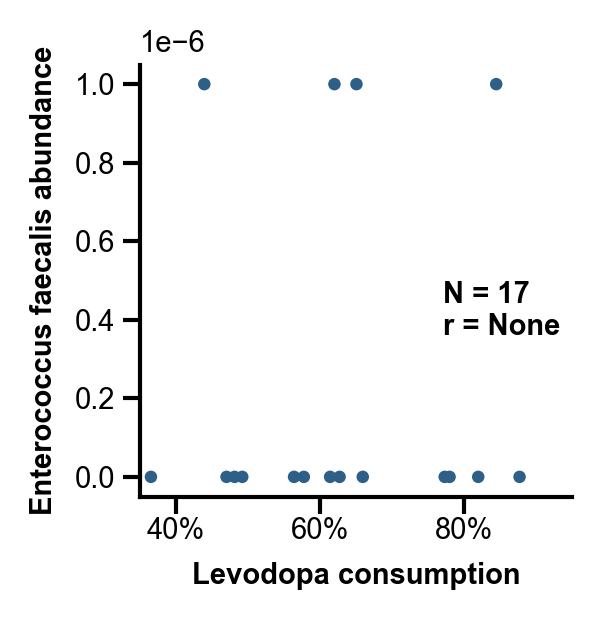

In [15]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

# ===== 数据准备 =====
keys = list(score_dict.keys())
# keys = [x for x in keys if x not in ['0609A', '0520A', '0506A']]
keys = [x for x in keys if x not in ['0520A', '0609A']]
x = [dopa_dict[k] for k in keys]
y = [score_dict[k] for k in keys]

# ===== Pearson 相关性 =====
# r, p = pearsonr(x, y)
# print(f"Pearson r = {r:.3f}, p = {p:.3e}")
# r, p = pearsonr(x, np.log10(y))
# print(f"Pearson r = {r:.3f}, p = {p:.3e}")
# ===== 画布 & 样式 =====
plt.figure(figsize=(1.8, 1.8), dpi=300)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

ax = plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_linewidth(0)
ax.set_position([0.2, 0.2, 0.8, 0.8]) 

# ===== 散点图 =====
plt.scatter(x, y, s=9, alpha=1, color='#2D5F89', edgecolors='none')

# 在点旁边显示 label
# for i, k in enumerate(keys):
#     plt.text(x[i], y[i], k, fontsize=6, ha="left", va="bottom")

# y轴对数
# plt.yscale("log")

# 在图上显示相关性
num = len(keys)
# plt.text(0.08, 0.95, f"N = {num}\nr = {r:.2f}\np = {p:.1e}",
#          transform=plt.gca().transAxes,
#          fontsize=7, fontweight='bold', va="top", ha='left')
plt.text(0.7, 0.5, f"N = {num}\nr = None",
         transform=plt.gca().transAxes,
         fontsize=7, fontweight='bold', va="top", ha='left')
# ===== 坐标轴 =====
plt.xlabel("Levodopa consumption", fontsize=7, fontweight='bold')
plt.ylabel("Enterococcus faecalis abundance", fontsize=7, fontweight='bold')
# plt.ylabel("Enterococcus faecalis abundance", fontsize=7, fontweight='bold')

plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)

plt.xlim(0.35, 0.95)
import matplotlib.ticker as mtick
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
# plt.ylim(1e8, 5.5e8)


plt.savefig('../../Figure/Figure-3c.pdf', dpi=400, bbox_inches='tight')
plt.show()